# Custom CNN 3-Class Image Classification with Keras

This notebook trains a custom CNN for the 3 classes `Amine`, `Jakub`, and `Rifki` using the existing folder structure in `../data`.

In [1]:
from pathlib import Path
from typing import List
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

print('TensorFlow:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))

TensorFlow: 2.21.0
GPU available: False


In [2]:
SEED = 42
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 16
EPOCHS = 30
CLASS_NAMES = ['Amine', 'Jakub', 'Rifki']
DATA_ROOT = Path('../data')
MODEL_PATH = Path('custom_cnn_3class.keras')

keras.utils.set_random_seed(SEED)

if not DATA_ROOT.exists():
    raise FileNotFoundError(f'Could not find dataset directory: {DATA_ROOT.resolve()}')

print('Data root:', DATA_ROOT.resolve())

Data root: /Users/jakubpiotrowski/PycharmProjects/HS-Codesign/data


In [3]:
def collect_split_dataframe(data_root: Path, class_names: List[str], split: str) -> pd.DataFrame:
    records = []
    valid_ext = {'.png', '.jpg', '.jpeg', '.bmp'}

    for class_name in class_names:
        split_dir = data_root / class_name / split
        if not split_dir.exists():
            raise FileNotFoundError(f'Missing split directory: {split_dir}')

        for file_path in sorted(split_dir.iterdir()):
            if file_path.is_file() and file_path.suffix.lower() in valid_ext:
                records.append({'filepath': str(file_path), 'label': class_name})

    if not records:
        raise ValueError(f'No images found for split={split!r}')

    df = pd.DataFrame(records)
    return df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)


train_df = collect_split_dataframe(DATA_ROOT, CLASS_NAMES, 'train')
test_df = collect_split_dataframe(DATA_ROOT, CLASS_NAMES, 'test')

display(train_df.head())
print('Train samples:', len(train_df))
print(train_df['label'].value_counts().sort_index())
print()
print('Test samples:', len(test_df))
print(test_df['label'].value_counts().sort_index())

,filepath,label
0,../data/Rifki/train/image_20260312_103722_shif...,Rifki
1,../data/Rifki/train/image_20260312_103932_shif...,Rifki
2,../data/Rifki/train/image_20260305_130116_rot.png,Rifki
3,../data/Amine/train/image_20260319_151224_comb...,Amine
4,../data/Jakub/train/image_20260219_163823_brig...,Jakub


Train samples: 3120
label
Amine    1040
Jakub    1040
Rifki    1040
Name: count, dtype: int64

Test samples: 780
label
Amine    260
Jakub    260
Rifki    260
Name: count, dtype: int64


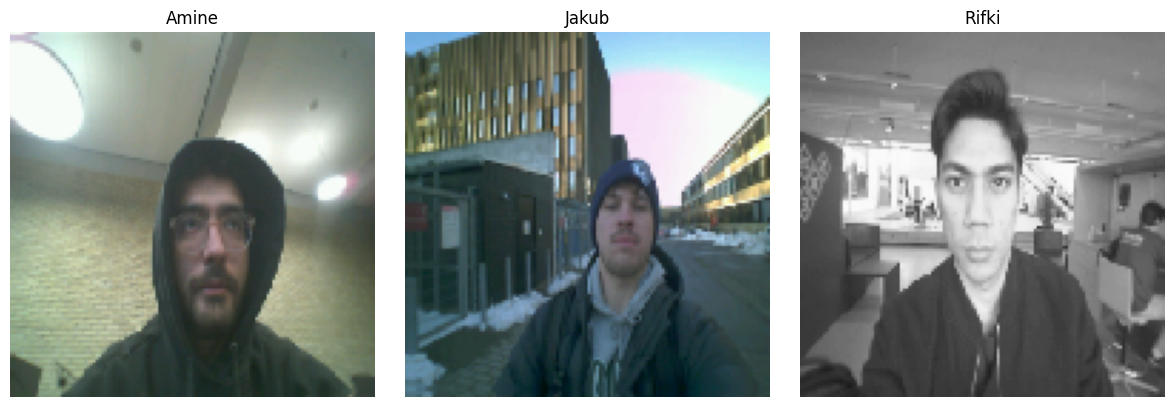

In [4]:
sample_paths = []
for class_name in CLASS_NAMES:
    class_rows = train_df[train_df['label'] == class_name]
    sample_paths.append(class_rows.sample(1, random_state=SEED).iloc[0]['filepath'])

plt.figure(figsize=(12, 4))
for i, image_path in enumerate(sample_paths, start=1):
    image = keras.utils.load_img(image_path, target_size=IMAGE_SIZE)
    plt.subplot(1, len(sample_paths), i)
    plt.imshow(image)
    plt.title(Path(image_path).parts[-3])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [5]:
train_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.1,
    brightness_range=(0.9, 1.1),
    horizontal_flip=True,
)

test_datagen = keras.preprocessing.image.ImageDataGenerator(rescale=1.0 / 255.0)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=IMAGE_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    subset='training',
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True,
)

val_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=IMAGE_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    subset='validation',
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False,
)

test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=IMAGE_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print('Class indices:', train_gen.class_indices)

Found 2496 validated image filenames belonging to 3 classes.
Found 624 validated image filenames belonging to 3 classes.
Found 780 validated image filenames belonging to 3 classes.
Class indices: {'Amine': 0, 'Jakub': 1, 'Rifki': 2}


In [6]:
def conv_block(x, filters: int, block_name: str):
    x = layers.Conv2D(filters, 3, padding='same', use_bias=False, name=f'{block_name}_conv1')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn1')(x)
    x = layers.ReLU(name=f'{block_name}_relu1')(x)
    x = layers.Conv2D(filters, 3, padding='same', use_bias=False, name=f'{block_name}_conv2')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn2')(x)
    x = layers.ReLU(name=f'{block_name}_relu2')(x)
    x = layers.MaxPooling2D(pool_size=2, name=f'{block_name}_pool')(x)
    return x


inputs = keras.Input(shape=IMAGE_SIZE + (3,))
x = conv_block(inputs, 32, 'block1')
x = conv_block(x, 64, 'block2')
x = conv_block(x, 128, 'block3')
x = layers.SeparableConv2D(192, 3, padding='same', use_bias=False, name='sep_conv1')(x)
x = layers.BatchNormalization(name='sep_bn1')(x)
x = layers.ReLU(name='sep_relu1')(x)
x = layers.SeparableConv2D(256, 3, padding='same', use_bias=False, name='sep_conv2')(x)
x = layers.BatchNormalization(name='sep_bn2')(x)
x = layers.ReLU(name='sep_relu2')(x)
x = layers.GlobalAveragePooling2D(name='gap')(x)
x = layers.Dropout(0.3, name='dropout1')(x)
x = layers.Dense(128, activation='relu', name='dense1')(x)
x = layers.Dropout(0.2, name='dropout2')(x)
outputs = layers.Dense(len(CLASS_NAMES), activation='softmax', name='classifier')(x)

model = keras.Model(inputs, outputs, name='CustomCNN3Class')
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()

Model: "CustomCNN3Class"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn1 (BatchNormalization) │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu1 (ReLU)             │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn2 (BatchNormalization) │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu2 (ReLU)             │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn1 (BatchNormalization) │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu1 (ReLU)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn2 (BatchNormalization) │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu2 (ReLU)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn1 (BatchNormalization) │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu1 (ReLU)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn2 (BatchNormalization) │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu2 (ReLU)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sep_conv1 (SeparableConv2D)     │ (None, 16, 16, 192)    │        25,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sep_bn1 (BatchNormalization)    │ (None, 16, 16, 192)    │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sep_relu1 (ReLU)                │ (None, 16, 16, 192)    │             

 Total params: 400,035 (1.53 MB)

 Trainable params: 398,243 (1.52 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [7]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    keras.callbacks.ModelCheckpoint(MODEL_PATH, monitor='val_loss', save_best_only=True, mode='min'),
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
)

model = keras.models.load_model(MODEL_PATH)

Epoch 1/30
156/156 ━━━━━━━━━━━━━━━━━━━━ 43s 260ms/step - accuracy: 0.7460 - loss: 0.6168 - val_accuracy: 0.3478 - val_loss: 1.1126 - learning_rate: 0.0010
Epoch 2/30
156/156 ━━━━━━━━━━━━━━━━━━━━ 42s 266ms/step - accuracy: 0.8025 - loss: 0.4819 - val_accuracy: 0.3478 - val_loss: 1.3967 - learning_rate: 0.0010
Epoch 3/30
156/156 ━━━━━━━━━━━━━━━━━━━━ 42s 268ms/step - accuracy: 0.8490 - loss: 0.3843 - val_accuracy: 0.7356 - val_loss: 0.6123 - learning_rate: 0.0010
Epoch 4/30
156/156 ━━━━━━━━━━━━━━━━━━━━ 41s 262ms/step - accuracy: 0.8562 - loss: 0.3579 - val_accuracy: 0.5609 - val_loss: 1.5190 - learning_rate: 0.0010
Epoch 5/30
156/156 ━━━━━━━━━━━━━━━━━━━━ 40s 253ms/step - accuracy: 0.8946 - loss: 0.2657 - val_accuracy: 0.5721 - val_loss: 2.6367 - learning_rate: 0.0010
Epoch 6/30
156/156 ━━━━━━━━━━━━━━━━━━━━ 40s 255ms/step - accuracy: 0.9123 - loss: 0.2289 - val_accuracy: 0.6074 - val_loss: 1.3890 - learning_rate: 0.0010
Epoch 7/30
156/156 ━━━━━━━━━━━━━━━━━━━━ 41s 265ms/step - accuracy: 0.9

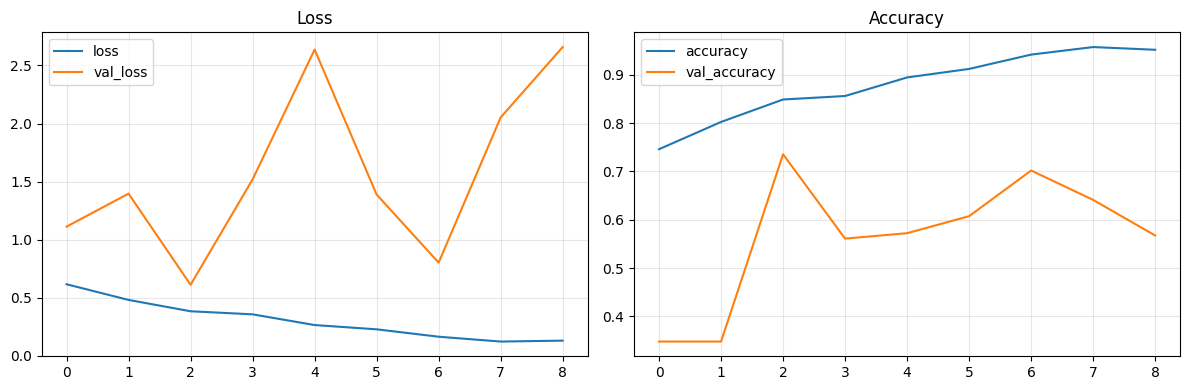

In [8]:
history_df = pd.DataFrame(history.history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

history_df[['loss', 'val_loss']].plot(ax=axes[0], title='Loss')
history_df[['accuracy', 'val_accuracy']].plot(ax=axes[1], title='Accuracy')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Test loss: 0.9730
Test accuracy: 0.5577

              precision    recall  f1-score   support

       Amine       0.63      0.62      0.62       260
       Jakub       0.47      0.71      0.57       260
       Rifki       0.66      0.35      0.46       260

    accuracy                           0.56       780
   macro avg       0.59      0.56      0.55       780
weighted avg       0.59      0.56      0.55       780



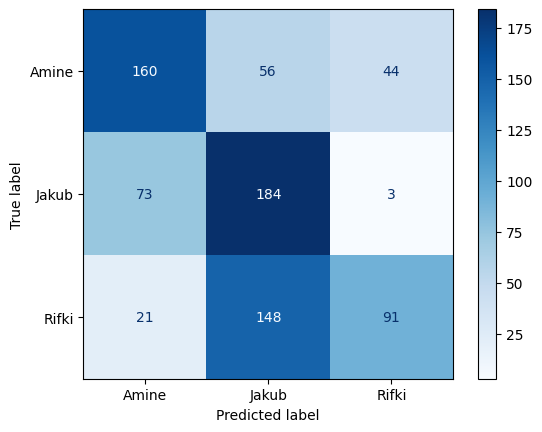

In [9]:
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

probabilities = model.predict(test_gen, verbose=0)
y_pred = np.argmax(probabilities, axis=1)
y_true = test_gen.classes

print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', values_format='d')
plt.show()

In [10]:
# for i in range(100):
index_to_class = {v: k for k, v in train_gen.class_indices.items()}
random_row = test_df.sample(1, random_state=random.randint(0, 10_000)).iloc[0]
# sample_path = random_row['filepath']
sample_path = "simf.jpeg"

image = keras.utils.load_img(sample_path, target_size=IMAGE_SIZE)
array = keras.utils.img_to_array(image) / 255.0
prediction = model.predict(np.expand_dims(array, axis=0), verbose=0)[0]
if np.max(prediction) < 0.95:
    print('Warning: Low confidence prediction (max score < 0.95)')
predicted_class = index_to_class[int(np.argmax(prediction))]

plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.title(f'True: {random_row["label"]} | Pred: {predicted_class}')
plt.axis('off')
plt.show()

for class_name, score in zip(CLASS_NAMES, prediction):
    print(f'{class_name}: {score:.4f}')

print('\nSaved model to:', MODEL_PATH.resolve())

FileNotFoundError: [Errno 2] No such file or directory: 'simf.jpeg'